In [1]:
import sys
sys.path.append('../src')
import importlib
import hsc_downloader
importlib.reload(hsc_downloader)
from hsc_downloader import download_hsc_cutout

hdul = download_hsc_cutout(ra_center=150.106, dec_center=2.22092, size_arcsec=108)
hdul.info()

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      20   ()      
  1                1 ImageHDU        44   (643, 644)   float32   
  2                1 ImageHDU         5   ()      
  3                1 ImageHDU         5   ()      


In [2]:
import os
print(repr(os.environ.get('SSP_PDR_USR')))

'yawpa'


In [3]:
import sys
sys.path.append('../src')
import importlib
import hsc_downloader
importlib.reload(hsc_downloader)
from hsc_downloader import download_hsc_cutout

hdul = download_hsc_cutout(ra_center=150.106, dec_center=2.22092, size_arcsec=108)
hdul.info()

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      20   ()      
  1                1 ImageHDU        44   (643, 644)   float32   
  2                1 ImageHDU         5   ()      
  3                1 ImageHDU         5   ()      


(644, 643) >f4
-0.038912345 300.60297 0.006947108


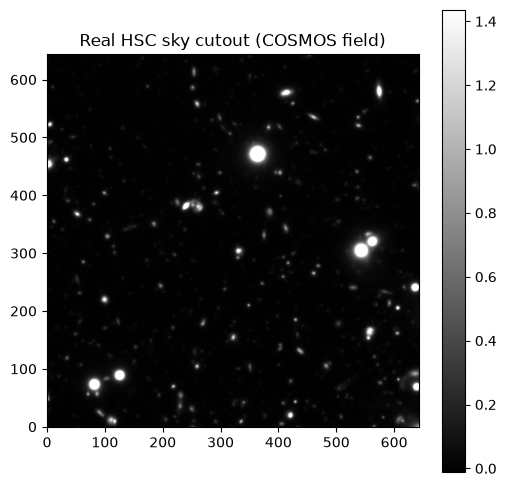

In [10]:
import numpy as np
import matplotlib.pyplot as plt
image_data = hdul[1].data
print(image_data.shape, image_data.dtype)
print(np.nanmin(image_data), np.nanmax(image_data), np.nanmedian(image_data))

plt.figure(figsize=(6, 6))
plt.imshow(image_data, cmap='gray', origin='lower',
           vmin=np.nanpercentile(image_data, 5), vmax=np.nanpercentile(image_data, 99.5))
plt.colorbar()
plt.title("Real HSC sky cutout (COSMOS field)")
plt.show()

In [11]:
header = hdul[1].header
print(repr(header))

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  643                                                  
NAXIS2  =                  644                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
COMMENT                                                                         
COMMENT                                                                         
COMMENT                                                                         
COMMENT                                                                         
COMMENT                                                                         
COMMENT                     

In [12]:
pixel_scale_arcsec = pixel_scales[0].to(u.arcsec).value
print(pixel_scale_arcsec)

0.1679999999999004


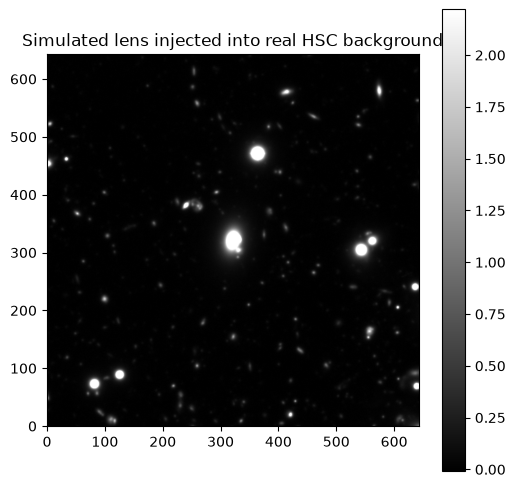

In [13]:
importlib.reload(lens_injector) if 'lens_injector' in dir() else None
import lens_injector
importlib.reload(lens_injector)
from lens_injector import inject_lens_into_background

result_injected = inject_lens_into_background(image_data, pixel_scale=pixel_scale_arcsec, is_lens=True, seed=500)

plt.figure(figsize=(6, 6))
plt.imshow(result_injected['image'], cmap='gray', origin='lower',
           vmin=np.nanpercentile(result_injected['image'], 5),
           vmax=np.nanpercentile(result_injected['image'], 99.5))
plt.colorbar()
plt.title("Simulated lens injected into real HSC background")
plt.show()

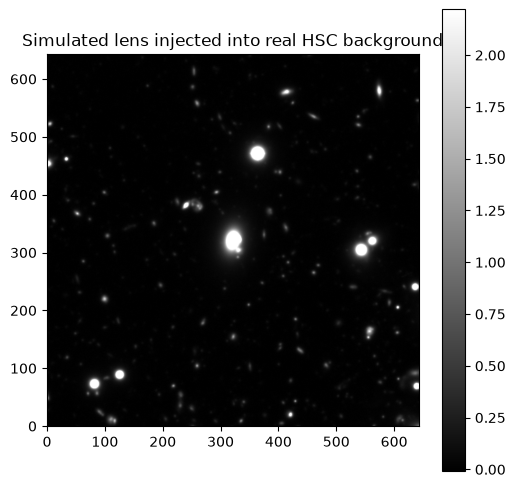

In [14]:
import lens_injector
importlib.reload(lens_injector)
from lens_injector import inject_lens_into_background

image_data = hdul[1].data

result_injected = inject_lens_into_background(image_data, pixel_scale=pixel_scale_arcsec, is_lens=True, seed=500)

plt.figure(figsize=(6, 6))
plt.imshow(result_injected['image'], cmap='gray', origin='lower',
           vmin=np.nanpercentile(result_injected['image'], 5),
           vmax=np.nanpercentile(result_injected['image'], 99.5))
plt.colorbar()
plt.title("Simulated lens injected into real HSC background")
plt.show()

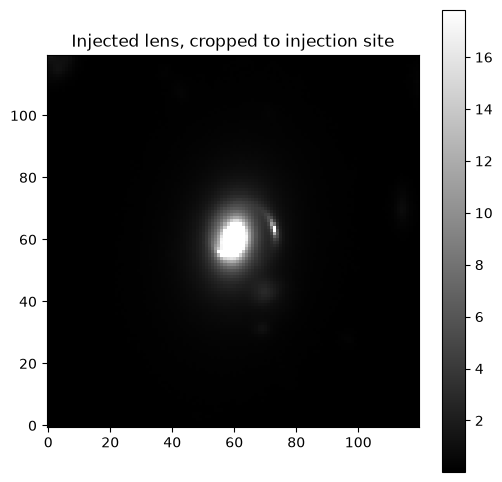

In [16]:
center = numPix = min(image_data.shape)
crop_size = 60
c = center // 2

cutout_injected = result_injected['image'][c - crop_size:c + crop_size, c - crop_size:c + crop_size]

plt.figure(figsize=(6, 6))
plt.imshow(cutout_injected, cmap='gray', origin='lower',
           vmin=np.nanpercentile(cutout_injected, 5), vmax=np.nanpercentile(cutout_injected, 99.5))
plt.colorbar()
plt.title("Injected lens, cropped to injection site")
plt.show()